# Business Intelligence (BI)

## Objective

This notebook answers strategic business questions regarding vehicle pricing, market trends, seller performance, geographic distribution, and premium vehicle sales to support business decision-making.

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('cleaned_vehicle_sales.csv')
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,...,sellingprice,saledate,vehicle_age,price_difference,price_ratio,sale_year,sale_month,sale_day,sale_weekday,sale_quarter
0,2015,Kia,Sorento,LX,Suv,Automatic,5xyktca69fg566472,ca,5.0,16639.0,...,21500.0,2014-12-16 04:30:00+00:00,-1,1000.0,1.048780,2014,December,16,Tuesday,4
1,2015,Kia,Sorento,LX,Suv,Automatic,5xyktca69fg561319,ca,5.0,9393.0,...,21500.0,2014-12-16 04:30:00+00:00,-1,700.0,1.033654,2014,December,16,Tuesday,4
2,2014,Bmw,3 Series,328i SULEV,Sedan,Automatic,wba3c1c51ek116351,ca,45.0,1331.0,...,30000.0,2015-01-14 20:30:00+00:00,1,-1900.0,0.940439,2015,January,14,Wednesday,1
3,2015,Volvo,S60,T5,Sedan,Automatic,yv1612tb4f1310987,ca,41.0,14282.0,...,27750.0,2015-01-28 20:30:00+00:00,0,250.0,1.009091,2015,January,28,Wednesday,1
4,2014,Bmw,6 Series Gran Coupe,650i,Sedan,Automatic,wba6b2c57ed129731,ca,43.0,2641.0,...,67000.0,2014-12-18 04:30:00+00:00,0,1000.0,1.015152,2014,December,18,Thursday,4


1. EXECUTIVE KPIs

1.1 Total Vehicle Sold

In [3]:
total_vehicles= len(df)
print(total_vehicles)

558799


1.2 Total revenue

In [4]:
total_revenue= df['sellingprice'].sum()
print(total_revenue)

7606012287.0


1.3 Average Sellingprice

In [5]:
avg_selling_price= df['sellingprice'].mean()
print(avg_selling_price)

13611.35629627111



1.4 Average  MMR

In [6]:
avg_mmr= df['mmr'].mean()
print(avg_mmr)

13769.377495306899


1.5 Average Vehicle Age

In [7]:
avg_vehicle_age= df['vehicle_age'].mean()
print(avg_vehicle_age)

4.8652198733354926


1.6 Average Odometer

In [8]:
avg_odometer= df['odometer'].mean()
print(avg_odometer)

68321.12718168787


1.7 Number Of Brands

In [9]:
brands_nuum= df['make'].nunique()
print(brands_nuum)

66


1.8 Number of Models

In [10]:
models_num=df['model'].nunique()
print(models_num)

973


1.9 Number Of Sellers

In [11]:
sellers_num= df['seller'].nunique()
print(sellers_num)

14260


10.0 Number of States

In [12]:
state_num= df['state'].nunique()
print(state_num)

38


2. MARKET INTELLIGENCE

2.1 Ques- Which brands dominate the market?

In [13]:
market_share= (df['make']
               .value_counts()
               .head(10)
               .reset_index()
)
market_share.columns=['Brand','Vehicle Sold']

Chart

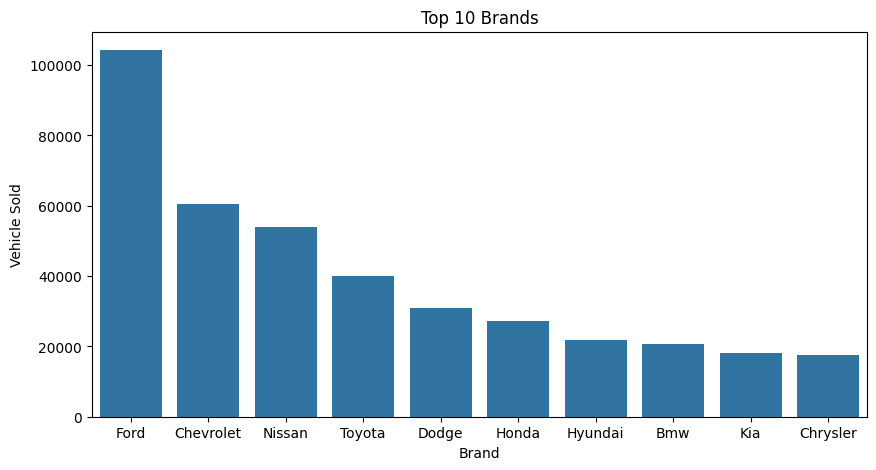

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(data=market_share,
            x='Brand',
            y='Vehicle Sold')
plt.title('Top 10 Brands')
plt.show()

Insights- Ford is the brand which highly dominates the market Because the frequency of the selling of the vehicles of ford brand is highest.

2.2 Ques- Market share by body type

In [15]:
body_type= df['body'].value_counts().reset_index()
body_type.columns=['Body', 'Vehicle Sold']

Chart

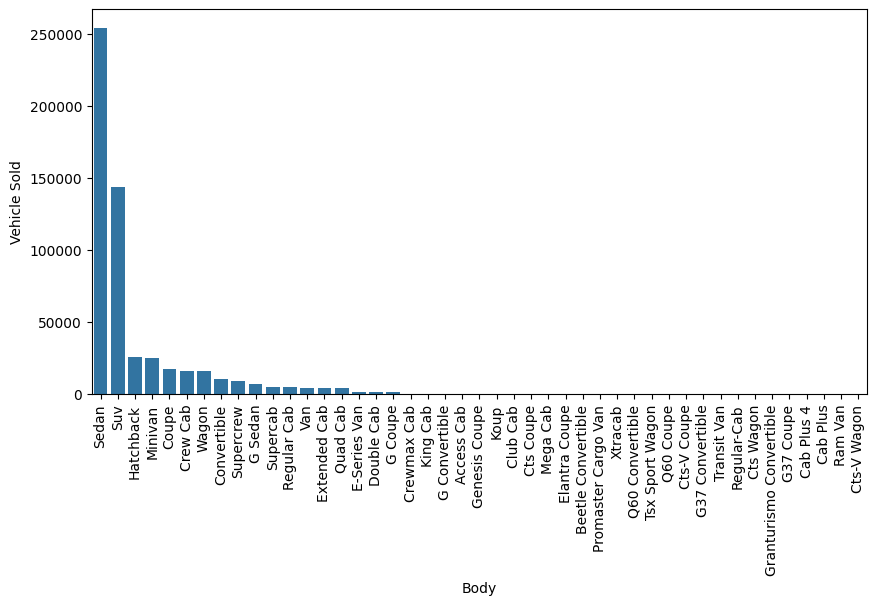

In [16]:
plt.figure(figsize=(10,5))
plt.xticks(rotation=90)
sns.barplot(data=body_type, x='Body', y='Vehicle Sold')
plt.show()

Insights- Sedan is the body type that dominates the market share, means most of the vehicles have the body- Sedan than SUV.

2.3 Ques- Automatic vs Manual market share

In [17]:
trans_share= df['transmission'].value_counts()

Chart

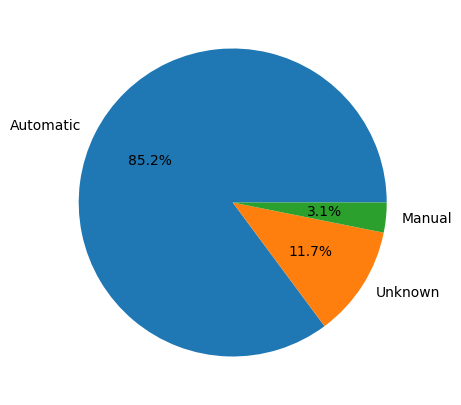

In [18]:
plt.figure(figsize=(10,5))
plt.pie(trans_share,
        labels=trans_share.index,
        autopct='%1.1f%%')
plt.show()

Insights- The value Count of the Automatic in the market is 85% and manual is only 3.1% 

It means that people are now focusing on the automatica cars.

3. PRICING INTELLIGENCE

3.1 Ques- Top 10 most expensive brands

In [19]:
top_10_expensive_brands= (df.groupby('make')['sellingprice']
                          .mean()
                          .sort_values(ascending=False)
                          .head(10)
                          .reset_index()
)                         


Chart

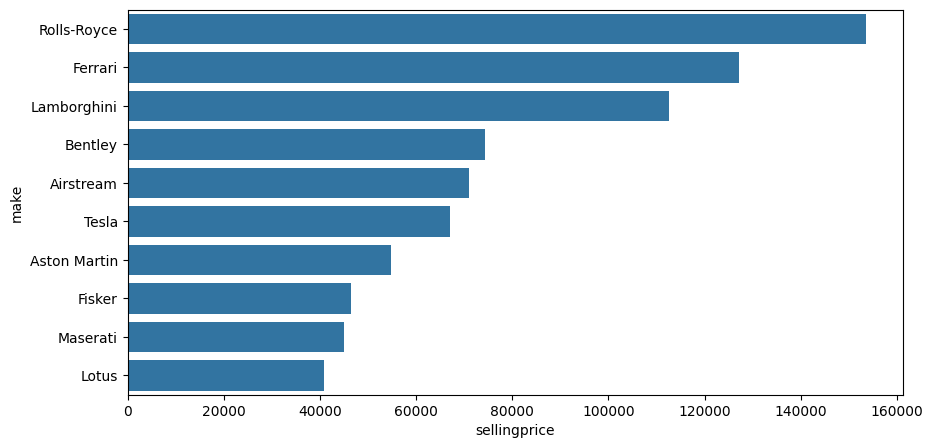

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_10_expensive_brands,
            x='sellingprice',
            y='make')
plt.show()

Insights- As we can see the Most expensive Vehicle brand that has max selling price is - Rolls Royce while the frequency of the Ford is the highest.


Means the Selling Price of the luxury vehicles generate more revenue through their selling price.

3.2 Average Price BY Body Type

In [21]:
avg_price_body= (df.groupby('body')['sellingprice'].mean()
                 .sort_values(ascending=False)
                 .reset_index())

Chart

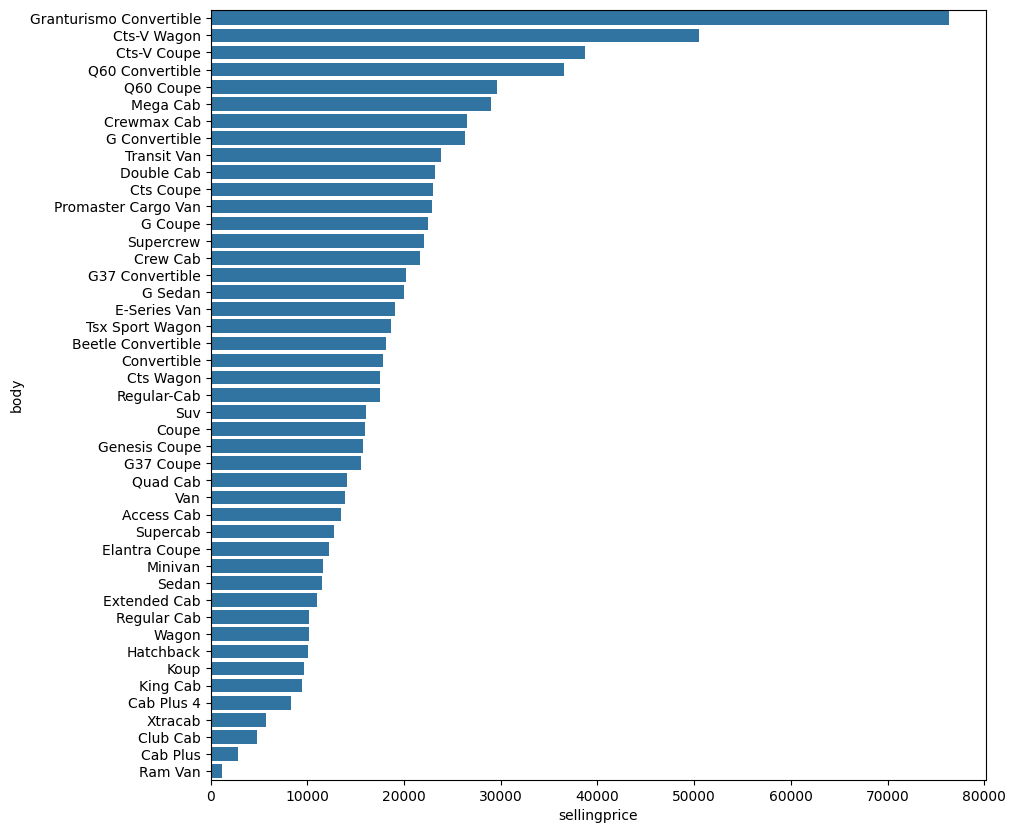

In [22]:
plt.figure(figsize=(10,10))
sns.barplot(data=avg_price_body,
            x='sellingprice',
            y='body')
plt.show()

Insights- The Body type Granturisuo affects more in the selling price while the Sedan dominates the market by its frequency.

3.3 Price Vs MMR

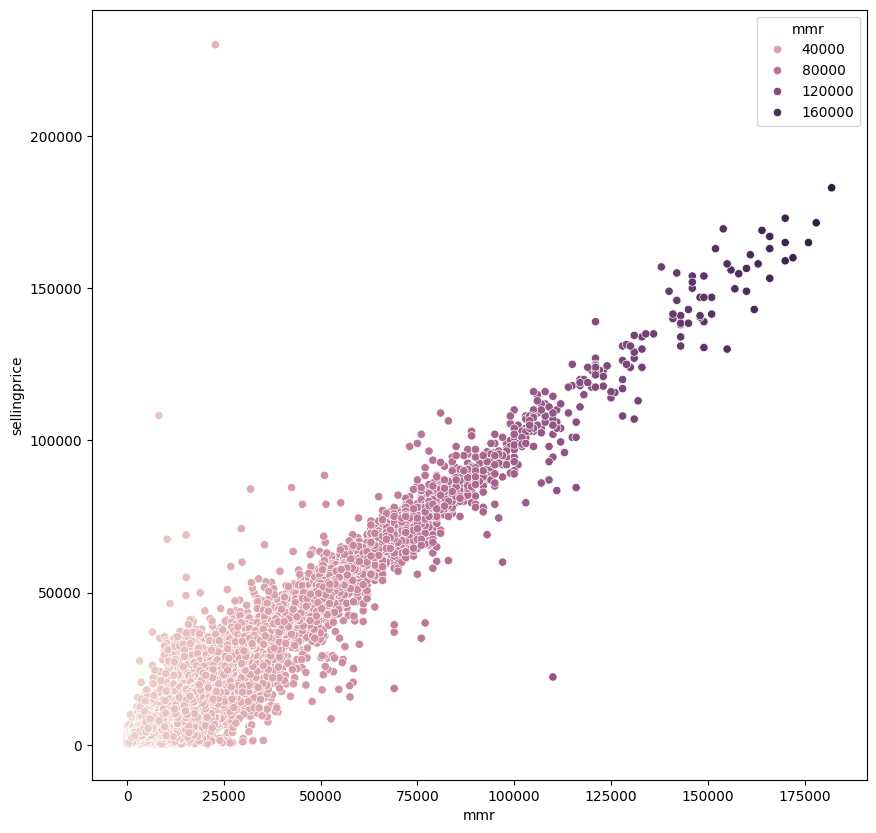

In [23]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df,
                x='mmr',
                y='sellingprice',
                hue='mmr')
plt.show()

Business Question

Are vehicles selling above or below market value?

Vehicles are selling below the market value , while  the mmr of the  vehicles are more than their selling price.

3.4 Ques- Vehicles sold above MMR

In [24]:
above=df[df['price_ratio']>1]

Count

In [25]:
len(above)

261161

Percentage

In [26]:
len(above)/len(df)*100

46.73612515412518

3.5 Ques- Most undervalued brands

In [27]:
under_valued= (df.groupby('make')['price_ratio']
               .mean()
               .head(10)
               .sort_values(ascending= True)
               .reset_index()
)


Chart

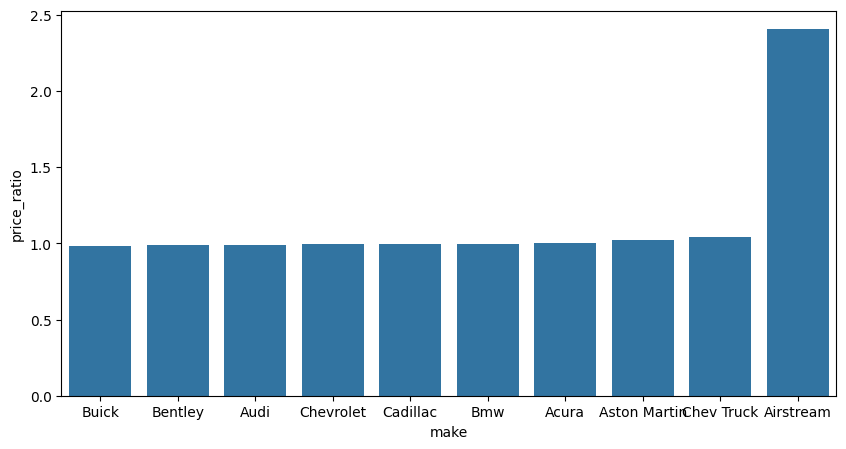

In [28]:
plt.figure(figsize=(10,5))
sns.barplot(data=under_valued,
            x='make',
            y='price_ratio')
plt.show()

Insights- MOst undervalued brand is Buick, Bentley because their price ratio is minimum .

It means that their market value and the sellingprice both are less.

4. SELLER INTELLIGENCE

4.1 Ques- Highest revenue sellers

In [6]:
revenue_seller= (df.groupby('seller')['sellingprice']
                 .sum()
                 .head(10)
                 .sort_values(ascending=False)
                 .reset_index())

Chart

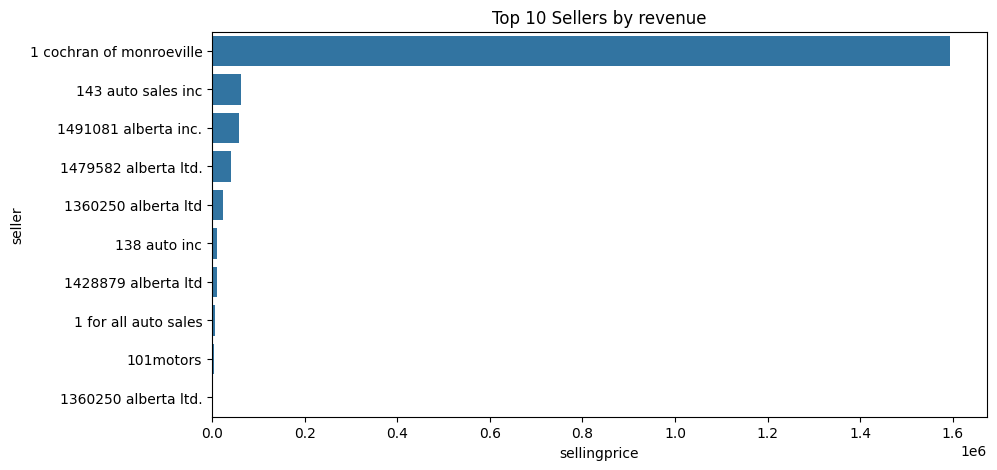

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(data=revenue_seller,
            x='sellingprice',
            y='seller')
plt.title('Top 10 Sellers by revenue')
plt.show()

Insights- The seller 1 cochran of monoeville generates the highest revenue.

4.2 Ques- Highest average selling price by seller

In [10]:
avg_seller_sellingprice= (df.groupby('seller')['sellingprice']
                 .mean()
                 .head(10)
                 .sort_values(ascending=False)
                 .reset_index())

Chart

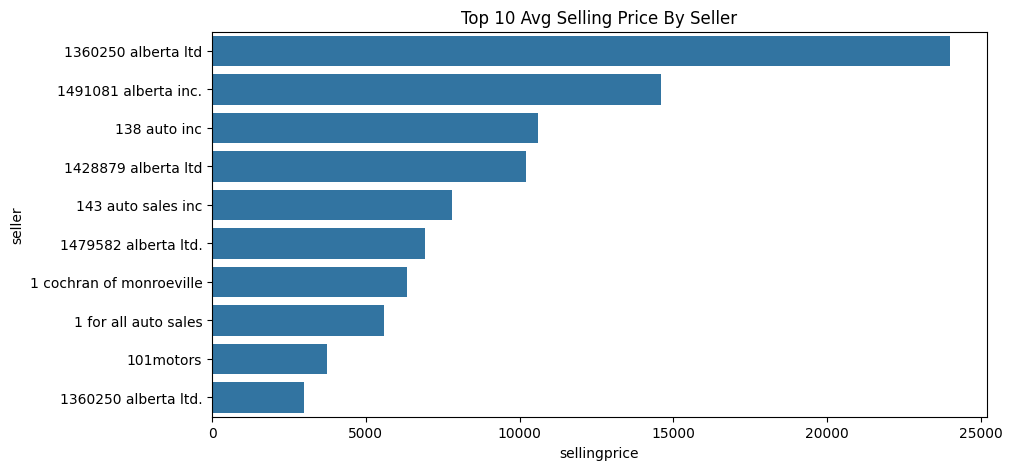

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(data=avg_seller_sellingprice,
            x='sellingprice',
            y='seller')
plt.title('Top 10 Avg Selling Price By Seller')
plt.show()

Insights- The seller 1360250 albert ltd has the highest avg selling price.

4.3 Ques- Number of vehicles sold

In [33]:
seller_vehicle= (df['seller'].value_counts().head(10).reset_index())
seller_vehicle.columns=['Seller', 'Vehicle Sold']


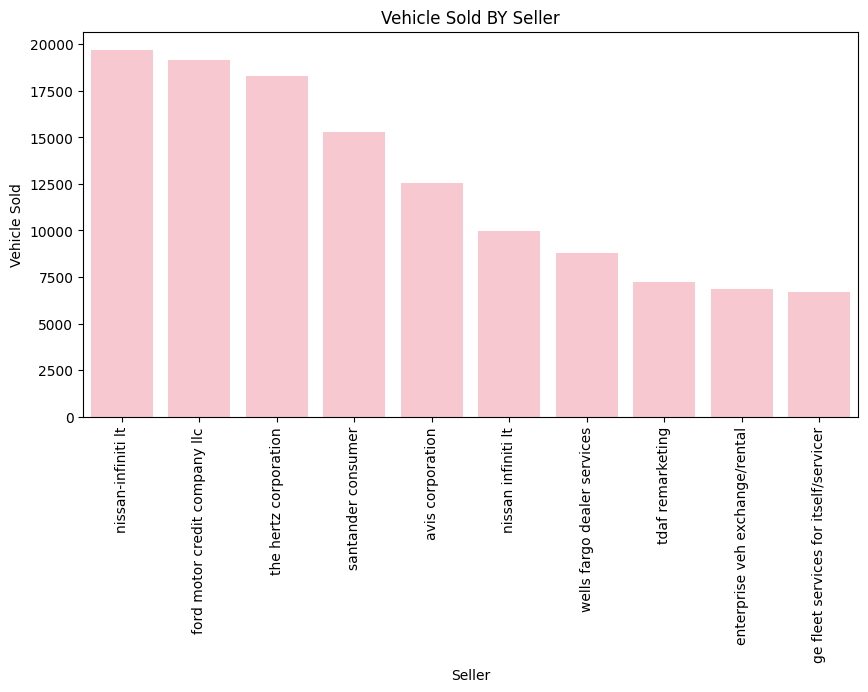

In [34]:
plt.figure(figsize=(10,5))
sns.barplot(data=seller_vehicle,
            x='Seller',
            y='Vehicle Sold',
            color='pink')
plt.title('Vehicle Sold BY Seller')
plt.xticks(rotation=90)
plt.show()

Insights- The seller Nissan-infiniti It sold the most vehicles but the highest revenue seller and highest avg selling price sellers are different.

5 GEOGRAPHIC INTELLIGENCE

5.1 Ques- Revenue by state

In [12]:
state_revenue= (df.groupby('state')['sellingprice'].sum().head(20).sort_values(ascending=False).reset_index())

Chart

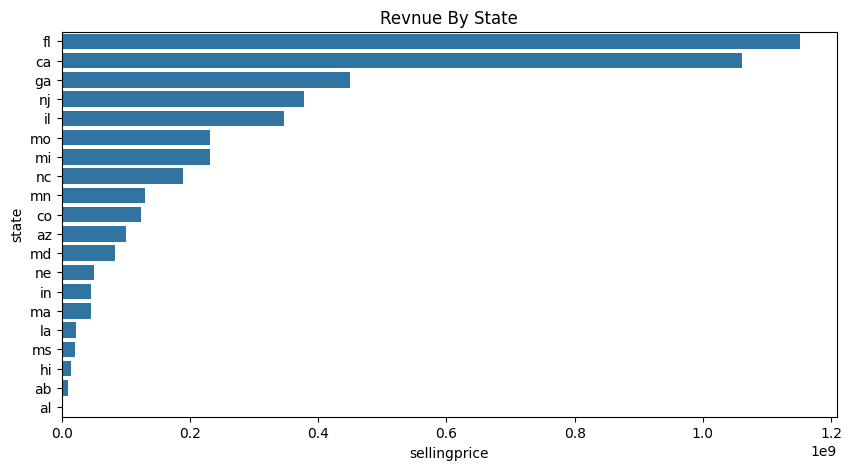

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(data=state_revenue,
            x='sellingprice',
            y='state')
plt.title('Revnue By State')
plt.show()

Insights- The state fl( Florida) generates the highest revenue in the market.

5.2 Ques- Top states by sales

In [37]:
top_states= df['state'].value_counts().head(20)
top_states

state
fl    82945
ca    73148
pa    53907
tx    45913
ga    34750
nj    27784
il    23478
nc    21845
oh    21575
tn    20895
mo    16013
mi    15511
nv    12685
va    12025
md    11157
wi     9851
mn     9429
az     8740
co     7775
wa     7416
Name: count, dtype: int64

Chart

5.3 Ques- Highest average selling price

In [38]:
avg_selling_price_state= (df.groupby('state')['sellingprice'].mean().tail(20).sort_values(ascending=False).reset_index())

Chart

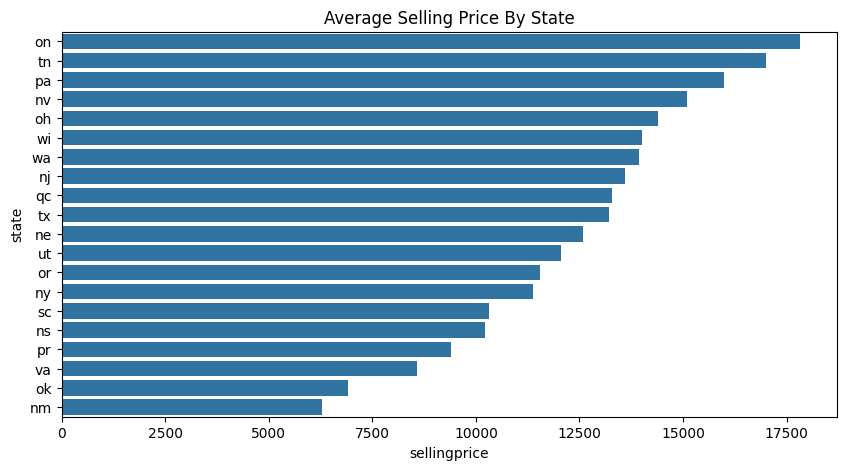

In [39]:
plt.figure(figsize=(10,5))
sns.barplot(data=avg_selling_price_state,
            x='sellingprice',
            y='state')
plt.title('Average Selling Price By State')
plt.show()

Insights- The State on(Ontario) , tn( Tennessee) than pa(Pennsylvania) has thee maximum avg selling price .

6. TIME INTELLIGENCE

6.1 Ques- Peak sales month- February

6.2 Ques- Lowest sales month- April and July

6.3 Ques- Peak quarter- 1

6.4 Ques- Highest revenue month- February

7. VEHICLE INTELLIGENCE

7.1 Ques- Average vehicle age by brand

In [40]:
vehicle_age_by_brand= (df.groupby('make')['vehicle_age'].mean()
                       .sort_values(ascending=False)
                       .reset_index())


Chart

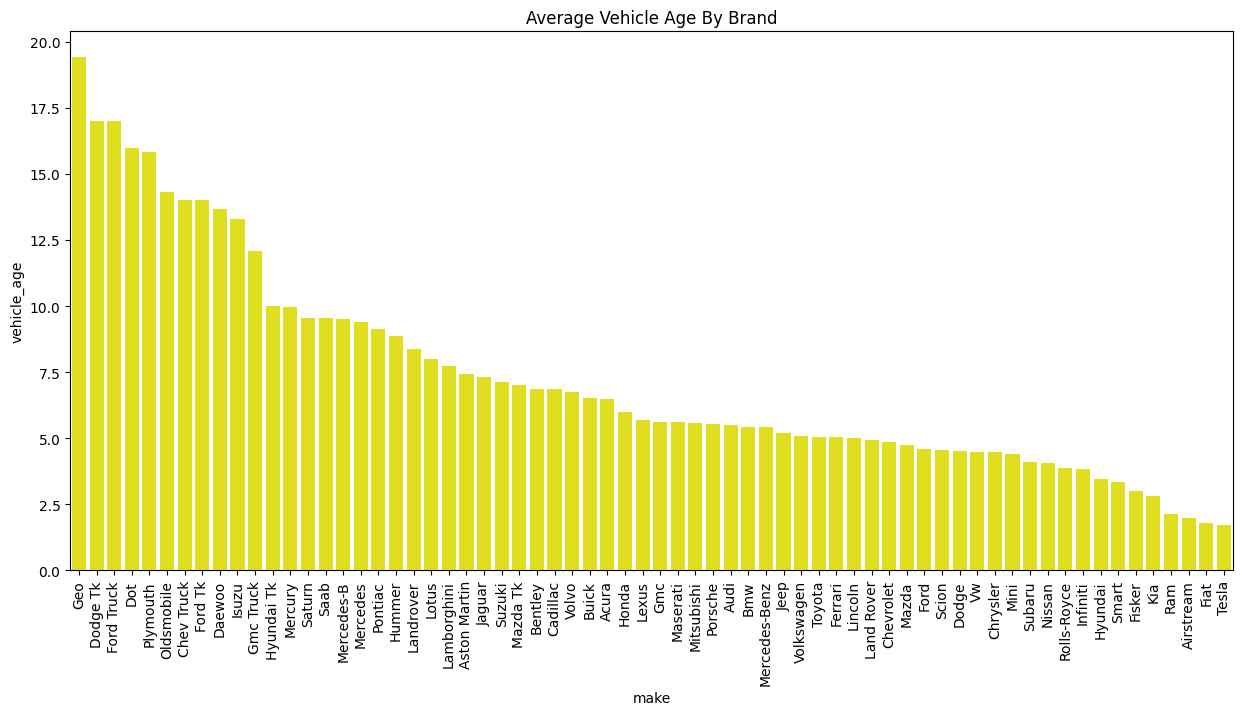

In [41]:
plt.figure(figsize=(15,7))
sns.barplot(data=vehicle_age_by_brand,
            x='make',
            y='vehicle_age', color='yellow')
plt.title('Average Vehicle Age By Brand')
plt.xticks(rotation=90)
plt.show()

Insights- Average vehicle age by different brands , The brand geo has maximum avg age.

7.2 Average Selling Price by Condition

In [42]:
avg_selling_by_condition= (df.groupby('condition')['sellingprice'].mean()
                       .sort_values(ascending=False)
                       .reset_index())

Chart

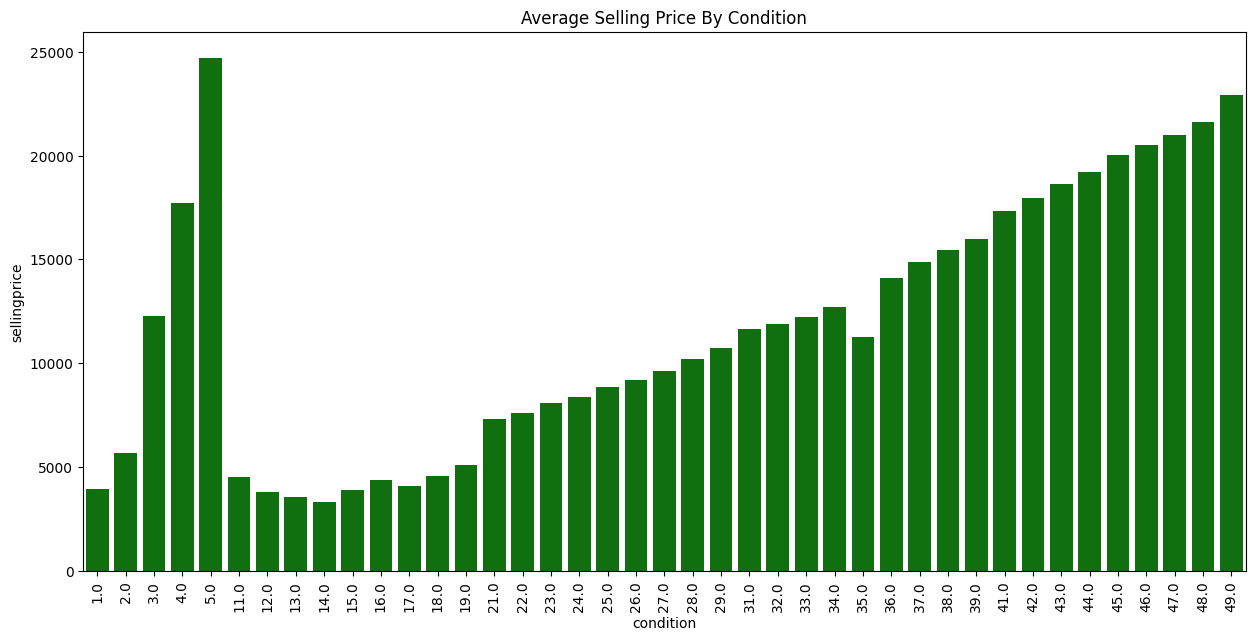

In [43]:
plt.figure(figsize=(15,7))
sns.barplot(data=avg_selling_by_condition,
            x='condition',
            y='sellingprice', color='green')
plt.title('Average Selling Price By Condition')
plt.xticks(rotation=90)
plt.show()

Insights- The Avg selling price of the vehicles at the agae of 5 is the highest but more high bars are lie on the right side of the chart indicates that the selling price of the vehcles with high condition is more .

7.3 Ques- Average Mileage By Body

In [44]:
mileage_body= (df.groupby('body')['odometer'].mean()
                       .sort_values(ascending=False)
                       .reset_index())

Chart

C:\Users\DELL\AppData\Local\Temp\ipykernel_2344\521636070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mileage_body,


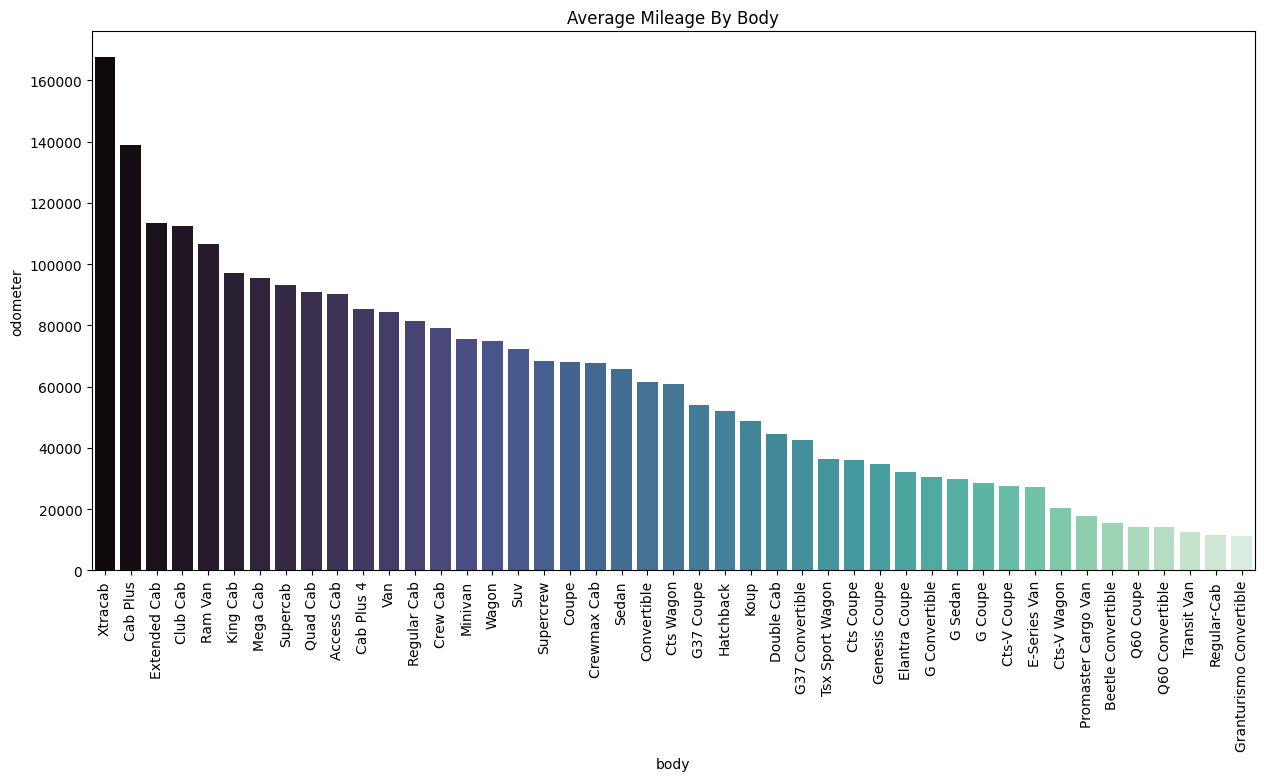

In [45]:
plt.figure(figsize=(15,7))
sns.barplot(data=mileage_body,
            x='body',
            y='odometer', palette='mako')
plt.title('Average Mileage By Body')
plt.xticks(rotation=90)
plt.show()

Insights- The avg mileage by body maximum mileage body is - Xtra cab but the lowest mileage body is granturisome which has highest avg selling price .

This indicates that the body with low mileage have high price and revenue.

8. PREMIUM MARKET INTELLIGENCE

8. Luxury Brands

In [46]:
premium=df[ df['sellingprice']> 50000]
premium

,year,make,model,trim,body,transmission,vin,state,condition,odometer,...,sellingprice,saledate,vehicle_age,price_difference,price_ratio,sale_year,sale_month,sale_day,sale_weekday,sale_quarter
4,2014,Bmw,6 Series Gran Coupe,650i,Sedan,Automatic,wba6b2c57ed129731,ca,43.0,2641.0,...,67000.0,2014-12-18 04:30:00+00:00,0,1000.0,1.015152,2014,December,18,Thursday,4
6,2014,Bmw,M5,Base,Sedan,Automatic,wbsfv9c51ed593089,ca,34.0,14943.0,...,65000.0,2014-12-17 04:30:00+00:00,0,-4000.0,0.942029,2014,December,17,Wednesday,4
19,2014,Bmw,6 Series,650i,Convertible,Automatic,wbayp9c53ed169260,ca,34.0,8819.0,...,67200.0,2014-12-17 04:30:00+00:00,0,-800.0,0.988235,2014,December,17,Wednesday,4
24,2014,Bmw,6 Series,650i,Convertible,Automatic,wbayp9c57ed169262,ca,38.0,10736.0,...,65000.0,2015-01-06 04:30:00+00:00,1,-2000.0,0.970149,2015,January,6,Tuesday,1
36,2015,Chevrolet,Suburban,LTZ,Suv,Automatic,1gnskkkc3fr187901,ca,45.0,11426.0,...,59900.0,2014-12-18 04:00:00+00:00,-1,2600.0,1.045375,2014,December,18,Thursday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558190,2013,Bmw,6 Series Gran Coupe,650i xDrive,Sedan,Unknown,wba6b4c5xdd098257,pa,41.0,30058.0,...,57600.0,2015-06-18 19:00:00+00:00,2,2300.0,1.041591,2015,June,18,Thursday,2
558452,2014,Mercedes-Benz,SL-Class,SL550,Convertible,Automatic,wddjk7da3ef022918,nv,5.0,4859.0,...,77500.0,2015-06-18 21:55:00+00:00,1,-2500.0,0.968750,2015,June,18,Thursday,2
558602,2014,Cadillac,Escalade,Platinum Edition,Suv,Automatic,1gys4def6er100019,nv,48.0,20649.0,...,62000.0,2015-06-18 21:55:00+00:00,1,-1000.0,0.984127,2015,June,18,Thursday,2
558769,2014,Mercedes-Benz,E-Class,E63 AMG 4MATIC,Sedan,Automatic,wddhf9cb9ea917688,ca,45.0,17518.0,...,69500.0,2015-07-07 02:30:00+00:00,1,5500.0,1.085938,2015,July,7,Tuesday,3


8.1 Ques- Which brands dominate premium segment?

In [47]:
premium_brand = (
    premium['make']
    .value_counts()
    .head(10)
    .reset_index()
)

premium_brand.columns = ['Brand', 'Premium Vehicles']
premium_brand

,Brand,Premium Vehicles
0,Bmw,725
1,Mercedes-Benz,620
2,Porsche,503
3,Chevrolet,319
4,Land Rover,192
5,Ford,166
6,Lexus,137
7,Audi,135
8,Bentley,92
9,Jaguar,86


Chart

C:\Users\DELL\AppData\Local\Temp\ipykernel_2344\3620048622.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


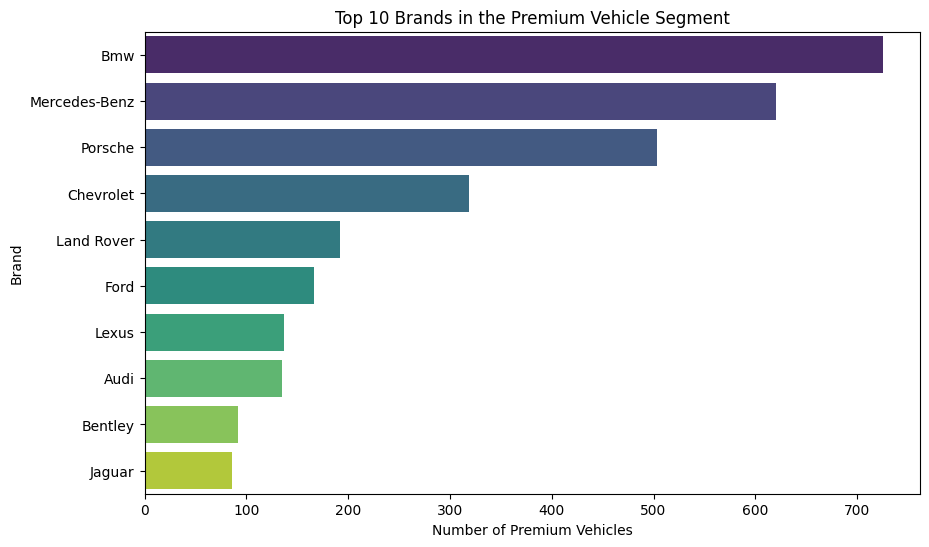

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=premium_brand,
    x='Premium Vehicles',
    y='Brand',
    palette='viridis'
)

plt.title("Top 10 Brands in the Premium Vehicle Segment")
plt.xlabel("Number of Premium Vehicles")
plt.ylabel("Brand")

plt.show()

Insights- The Brand BMW dominates more the premium segment.

as the maximum vehicles of  BMW lie in the premium category.

8.2  Ques- Which states buy premium vehicles?

In [49]:
premium_state = (
    premium['state']
    .value_counts()
    .head(10)
    .reset_index()
)

premium_state.columns = ['State', 'Premium Vehicles']
premium_state

,State,Premium Vehicles
0,ca,992
1,fl,584
2,pa,438
3,oh,279
4,ga,230
5,tx,212
6,nj,202
7,nv,132
8,tn,91
9,wi,56


Chart

C:\Users\DELL\AppData\Local\Temp\ipykernel_2344\3156834290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


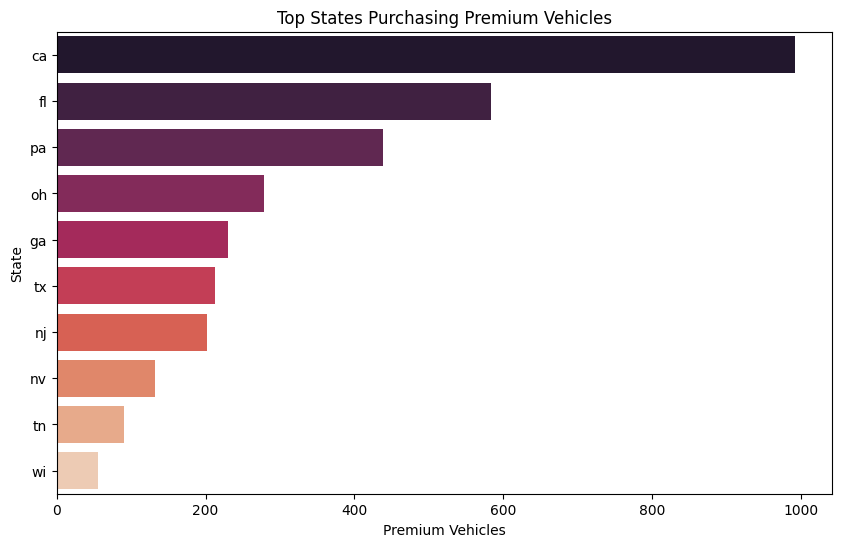

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=premium_state,
    x='Premium Vehicles',
    y='State',
    palette='rocket'
)

plt.title("Top States Purchasing Premium Vehicles")

plt.show()

Insights- The state ca(california) sells more premimum vehicles than florida.

8.3 Ques- Which Seller sells luxury Vehicle?

In [51]:
premium_seller = (
    premium['seller']
    .value_counts()
    .head(15)
    .reset_index()
)

premium_seller.columns = ['Seller', 'Luxury Vehicles Sold']

Chart

C:\Users\DELL\AppData\Local\Temp\ipykernel_2344\732764809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


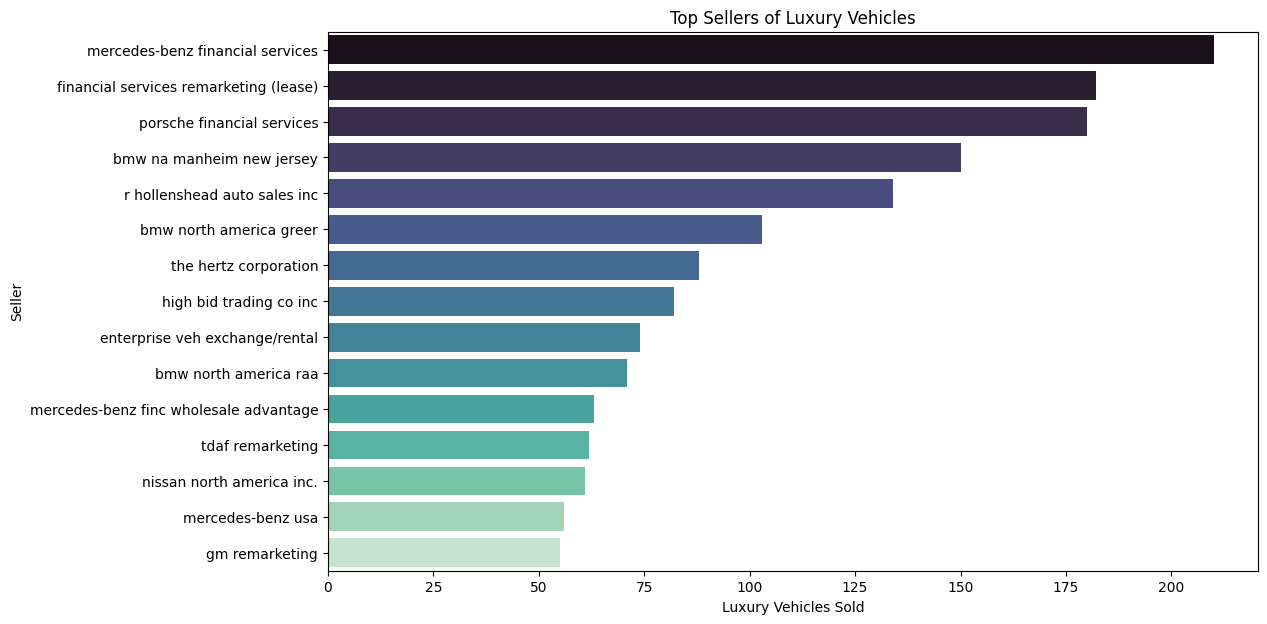

In [52]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=premium_seller,
    x='Luxury Vehicles Sold',
    y='Seller',
    palette='mako'
)

plt.title("Top Sellers of Luxury Vehicles")

plt.show()

Inisights- The seller Mercedes-benz financial services sells the more premium brands inn the market.

8.4 Ques- Which sellers generate the highest luxury revenue?

In [53]:
luxury_revenue= (premium.groupby('seller')['sellingprice']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())
luxury_revenue

,seller,sellingprice
0,porsche financial services,12415450.0
1,mercedes-benz financial services,12320950.0
2,financial services remarketing (lease),10698925.0
3,bmw na manheim new jersey,9617200.0
4,r hollenshead auto sales inc,9250450.0
5,bmw north america greer,6521300.0
6,high bid trading co inc,6015000.0
7,the hertz corporation,5912719.0
8,bmw north america raa,4740250.0
9,mercedes-benz usa,4393000.0


Chart

C:\Users\DELL\AppData\Local\Temp\ipykernel_2344\1084512244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


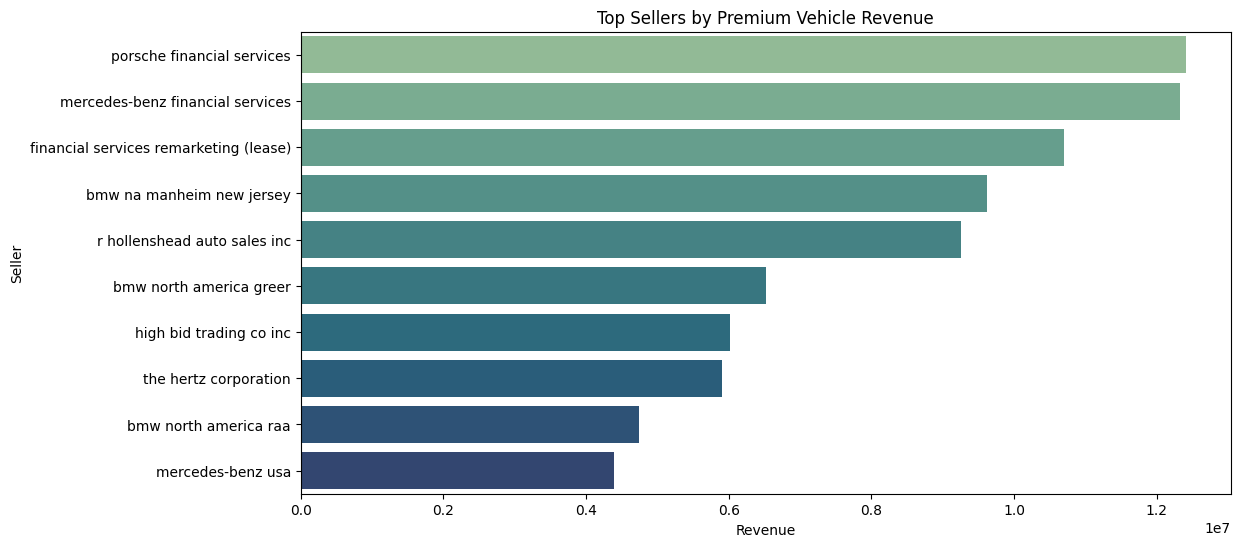

In [54]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=luxury_revenue,
    x='sellingprice',
    y='seller',
    palette='crest'
)

plt.title("Top Sellers by Premium Vehicle Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller")

plt.show()

Insights- The seller Porshe financil services generates the highest premium luxury revenue than 2nd is mercedes.

8.5 Ques- Which luxury brands have the highest average selling price?

In [55]:
luxury_avg_selling_price= (premium.groupby('make')['sellingprice']
                 .mean()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())
luxury_avg_selling_price

,make,sellingprice
0,Rolls-Royce,153488.235294
1,Ferrari,127210.526316
2,Lamborghini,112625.000000
3,Bentley,82158.152174
4,Nissan,73405.737705
5,Land Rover,73296.354167
6,Airstream,71000.000000
7,Audi,70472.222222
8,Tesla,67863.636364
9,Jaguar,67805.244186


Chart

C:\Users\DELL\AppData\Local\Temp\ipykernel_2344\1288858952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


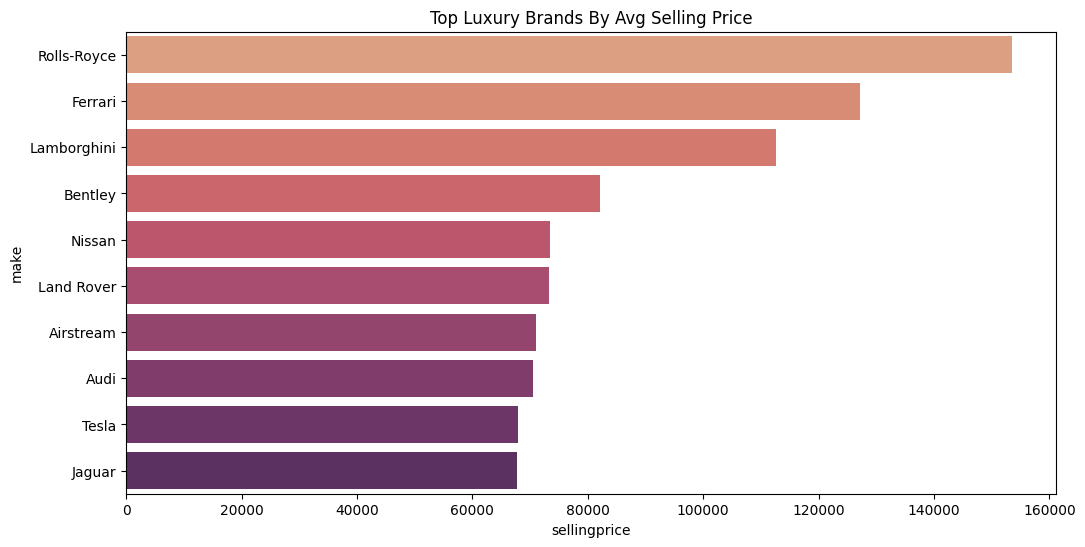

In [56]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=luxury_avg_selling_price,
    x='sellingprice',
    y='make',
    palette='flare'
)

plt.title("Top Luxury Brands By Avg Selling Price")

plt.show()

This answers:

Which premium brand commands the highest prices on average?

Rolls- Royce then Ferrari

8.6 Ques- Premium Vehicle Body Types

In [57]:
premium_body = (
    premium['body']
    .value_counts()
    .reset_index()
)

premium_body.columns = ['Body Type', 'Count']

Chart

C:\Users\DELL\AppData\Local\Temp\ipykernel_2344\4028839129.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


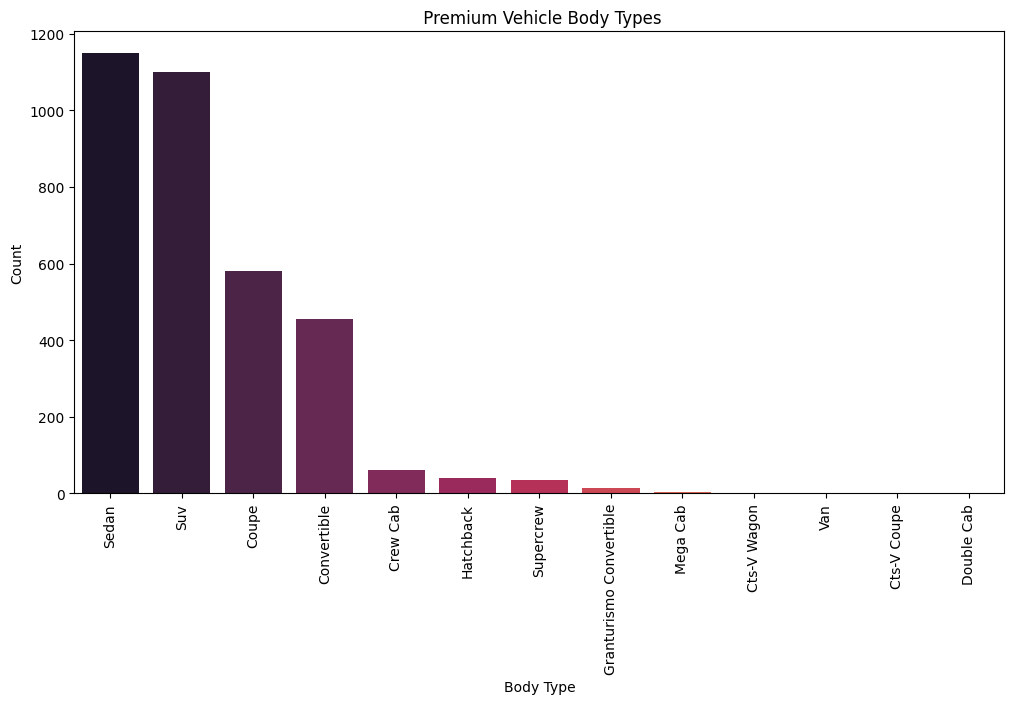

In [58]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=premium_body,
    x='Body Type',
    y='Count',
    palette='rocket'
)

plt.title(" Premium Vehicle Body Types")
plt.xticks(rotation=90)

plt.show()

Inisights- Thhe most of the premiumvehicles has the body types Sedan and SUV.

9. FINAL BUSINESS RECOMMENDATIONS

Recommendation 1

Ford and Chevrolet account for the largest share of vehicle sales. Dealerships should maintain higher inventory levels for these brands to meet customer demand.

Recommendation 2

Luxury brands consistently achieve higher average selling prices. Sellers can improve profitability by expanding premium vehicle offerings where market demand supports them.

Recommendation 3

Vehicles in better condition command higher selling prices. Encouraging inspections and refurbishment before resale could increase revenue.

Recommendation 4

Certain states contribute a larger share of revenue than others. Marketing campaigns and inventory allocation should prioritize these high-performing regions.

Recommendation 5

On average, vehicles were sold slightly below their MMR value, with an average price difference of -158.02. This suggests that transaction prices closely followed the estimated market value, with a small overall discount.